In [1]:
# Import required libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [15]:
# Open a file chooser to upload the dataset (train.csv)
# This allows the user to select the dataset directly from their computer

uploaded = files.upload()

# Read the uploaded CSV file into a pandas dataframe
data = pd.read_csv(next(iter(uploaded)))

# Display the first few rows of the dataset
data.head()

Saving train - Walmart Sales Forecast.csv to train - Walmart Sales Forecast (1).csv


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,"February 5, 2010",24924.50,False
1,1,1,"February 12, 2010",46039.49,True
2,1,1,"February 19, 2010",41595.55,False
3,1,1,"February 26, 2010",19403.54,False
4,1,1,"March 5, 2010",21827.90,False


In [16]:
# Display the structure of the dataset
print("Dataset Shape:", data.shape)

# Show column names
print("Columns in Dataset:", data.columns)

# Display summary statistics
data.describe()

Dataset Shape: (421570, 5)
Columns in Dataset: Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


/tmp/ipykernel_149/701877108.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data.resample('M', on='Date')['Weekly_Sales'].sum()


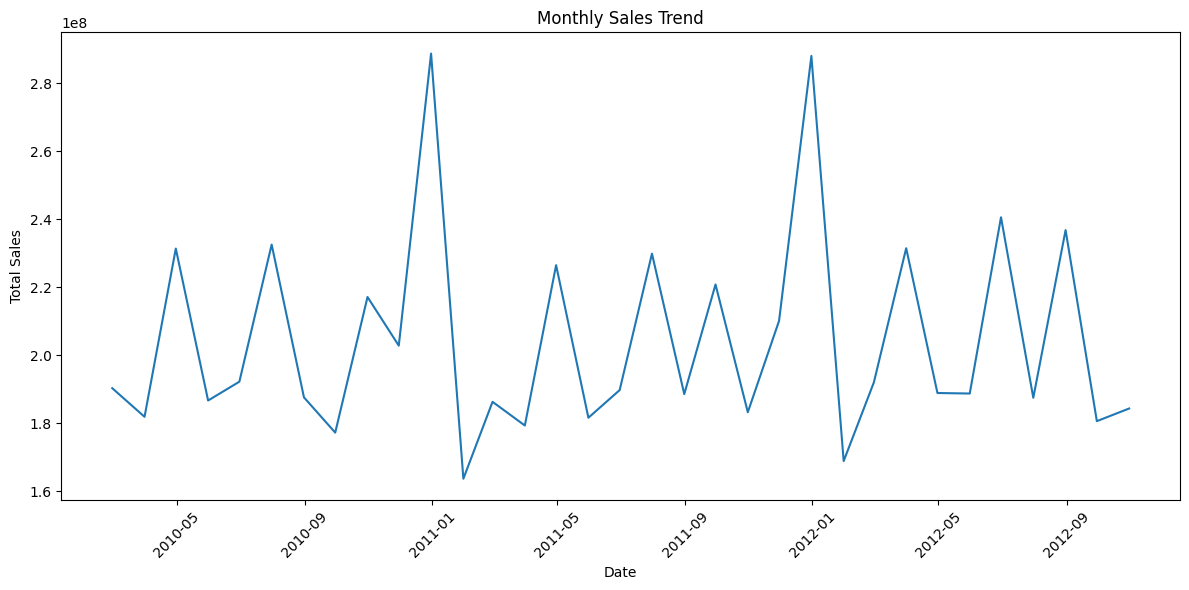

In [19]:
# Aggregate weekly sales into monthly sales totals
monthly_sales = data.resample('M', on='Date')['Weekly_Sales'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12,6))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

# Rotate labels to make them readable
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

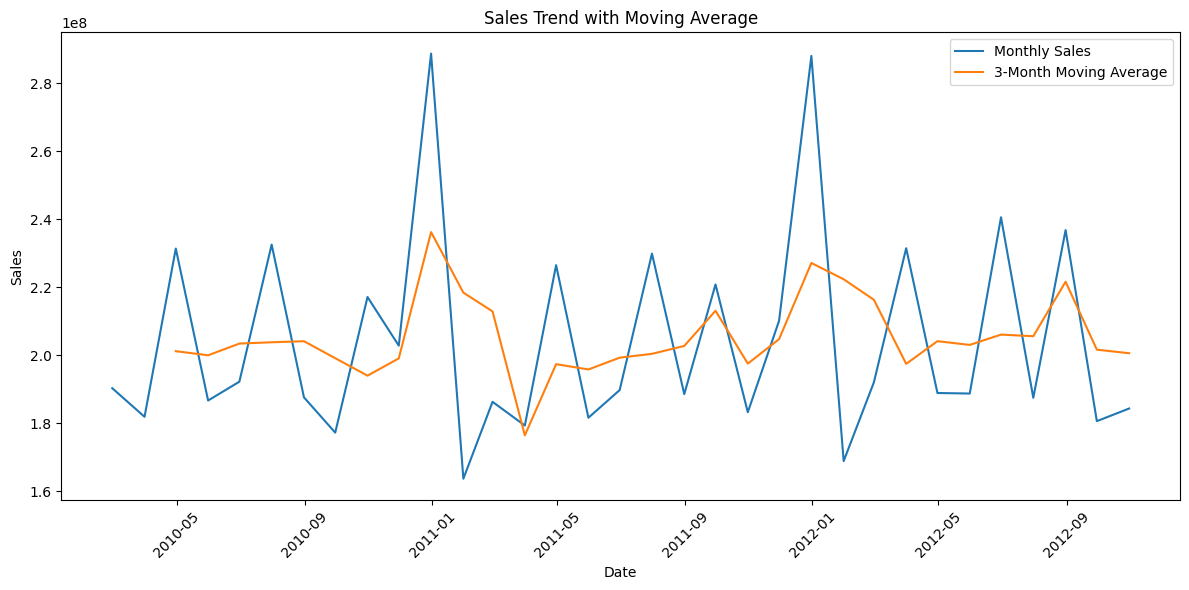

In [20]:
# Calculate a 3-month moving average
moving_avg = monthly_sales.rolling(window=3).mean()

# Plot monthly sales and moving average
plt.figure(figsize=(12,6))

plt.plot(monthly_sales, label="Monthly Sales")
plt.plot(moving_avg, label="3-Month Moving Average")

plt.title("Sales Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

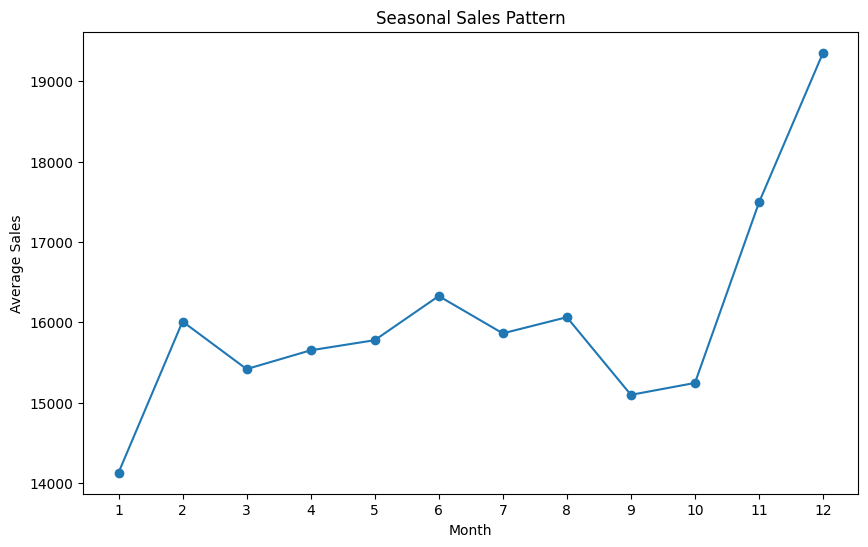

In [21]:
# Extract month from date
data['Month'] = data['Date'].dt.month

# Calculate average sales per month
seasonality = data.groupby('Month')['Weekly_Sales'].mean()

# Plot seasonal pattern
plt.figure(figsize=(10,6))

plt.plot(seasonality, marker='o')

plt.title("Seasonal Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Sales")

# Show months 1-12 clearly
plt.xticks(range(1,13))

plt.show()

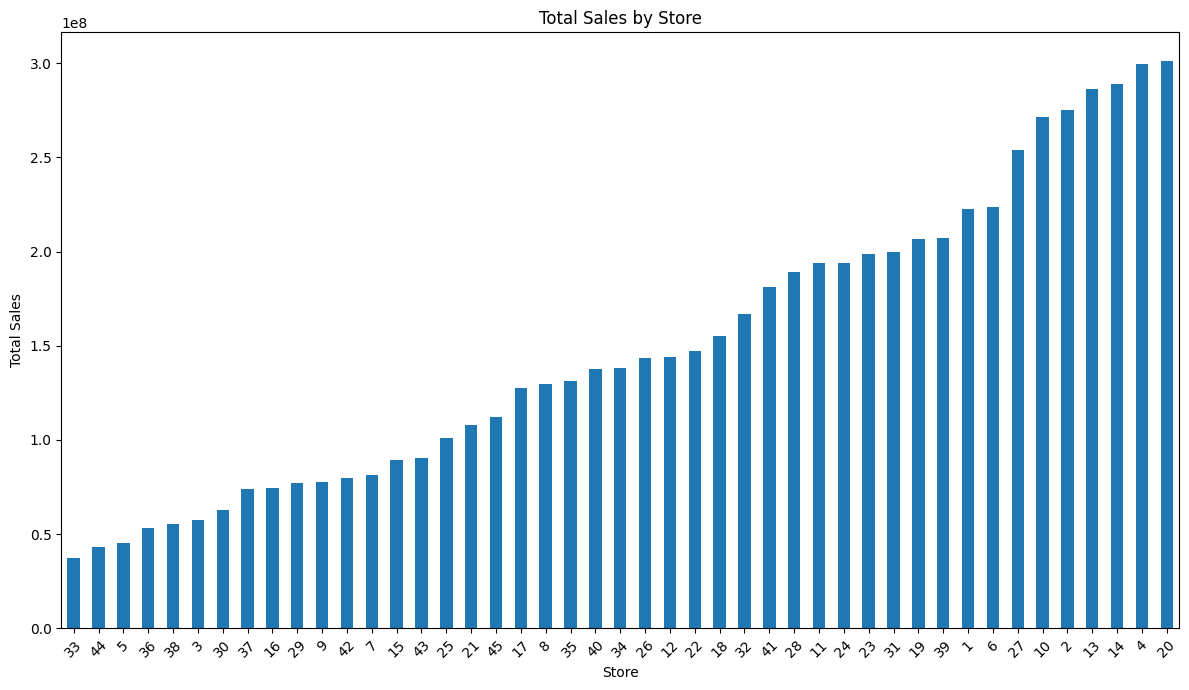

In [22]:
# Calculate total sales per store
store_sales = data.groupby('Store')['Weekly_Sales'].sum().sort_values()

# Plot store comparison
plt.figure(figsize=(12,7))

store_sales.plot(kind='bar')

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

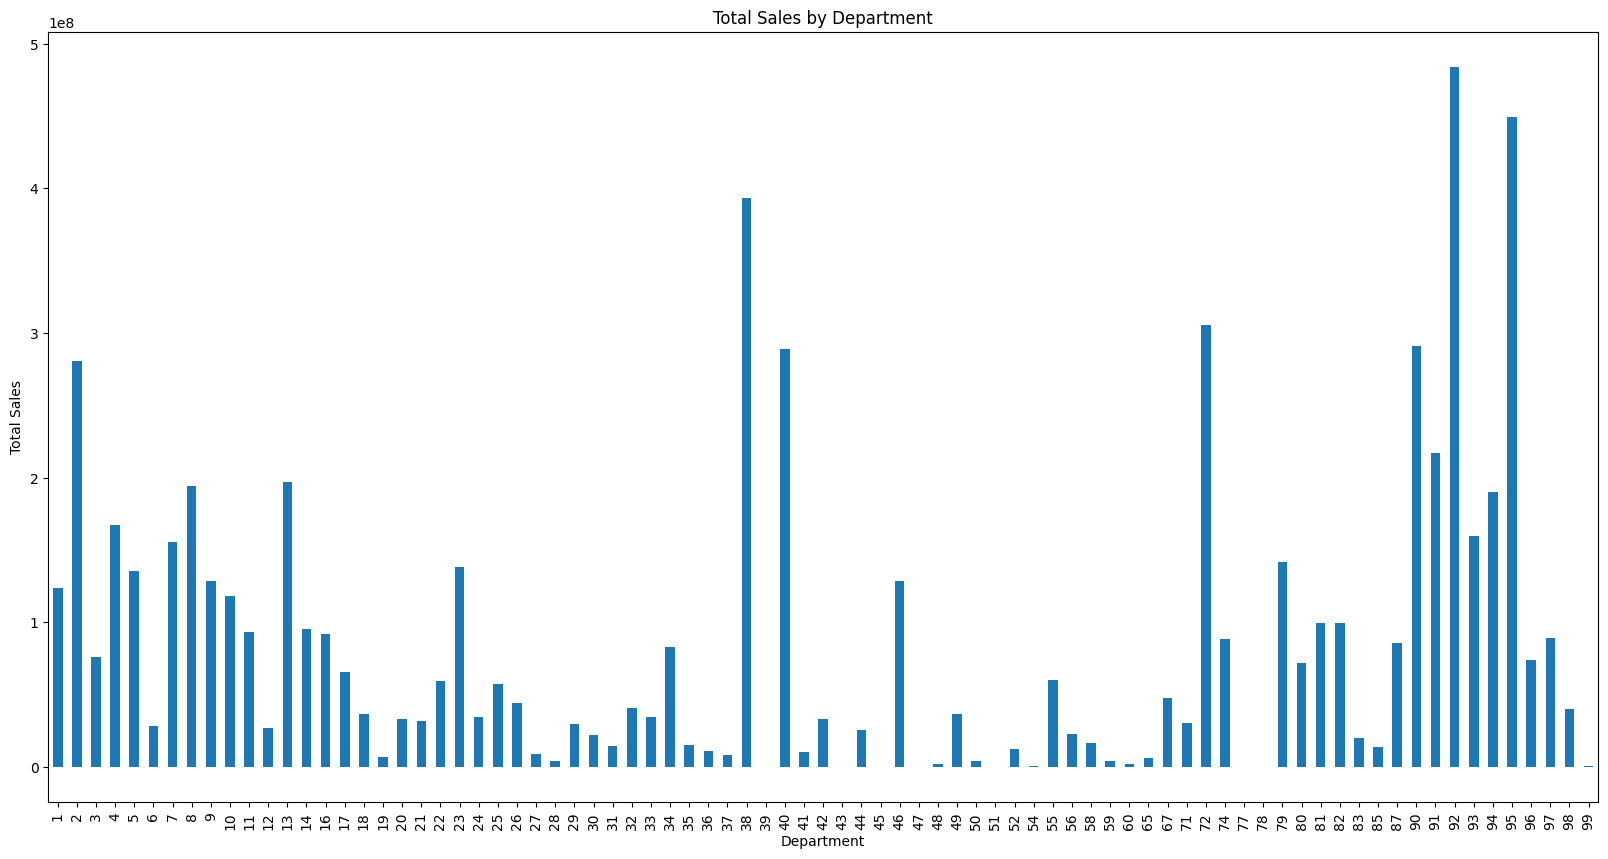

In [27]:
# Calculate total sales for each department
dept_sales = data.groupby('Dept')['Weekly_Sales'].sum()

# Plot department sales
plt.figure(figsize=(20,10))

dept_sales.plot(kind='bar')

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.show()

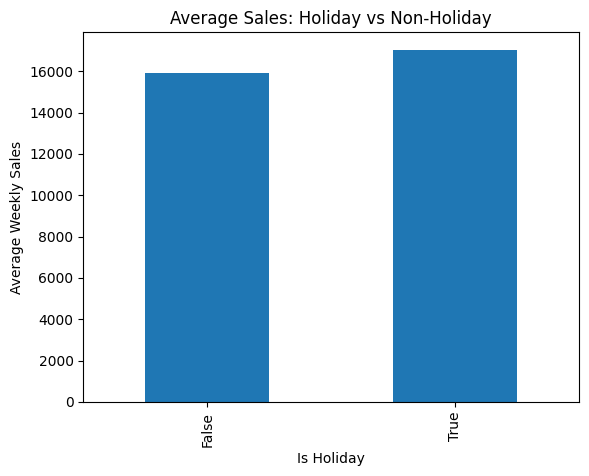

In [10]:
# Compare average sales during holidays and non-holidays
holiday_sales = data.groupby('IsHoliday')['Weekly_Sales'].mean()

# Plot comparison
plt.figure()

holiday_sales.plot(kind='bar')

plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Weekly Sales")

plt.show()